In [1]:
import numpy as np
def load_artifacts(path: str):
    z = np.load(path, allow_pickle=False)
    data = {k: z[k] for k in z.files}
    data["num_angles"] = int(data["num_angles"])
    data["num_actions"] = int(data["num_actions"])
    data["allow_only_forward"] = bool(int(data["allow_only_forward"]))
    data["allow_diagonal_obstacle"] = bool(int(data["allow_diagonal_obstacle"]))
    data["goal"] = tuple(int(x) for x in data["goal"])
    data["start_train"] = tuple(int(x) for x in data["start_train"])
    data["grid_sha1"] = str(data["grid_sha1"][0])
    data["note"] = str(data["note"][0])
    return data

def rebuild_env_from_artifacts(art):
    from rl_differential import GridWorld 
    H, W = art["grid"].shape
    env = GridWorld(
        width=W, height=H,
        grid_map=art["grid"],
        allow_only_forward=art["allow_only_forward"],
        allow_diagonal_obstacle=art["allow_diagonal_obstacle"],
        goal=art["goal"],
        use_reward_shaping=False,
    )
    # Lock motion model exactly as trained
    assert art["action_table"].shape == (art["num_angles"], art["num_actions"], 3)
    env._action_lookup = art["action_table"].astype(int, copy=False)
    return env

def rebuild_agent_from_artifacts(env, art):
    from rl_differential import QLearningAgent  # replace with your actual module name
    Q = art["Q"].astype(np.float32, copy=False)
    assert Q.shape == (env.height, env.width, env.num_angles, env.num_actions)
    agent = QLearningAgent(env, alpha=0.1, gamma=0.99, min_epsilon=0.0, max_epsilon=0.0)
    agent.Q = Q
    agent.epsilon = 0.0
    return agent

def rollout_greedy_from_start(env, agent, start, max_steps=None):
    if max_steps is None:
        max_steps = env.height * env.width * 4
    if not env.reset_new_position(start):
        return [], "blocked_start"
    seen, s, path = set(), env.agent_pos, [env.agent_pos]
    for _ in range(max_steps):
        if s == env.goal: return path, "reached_goal"
        if s in seen:     return path, "cycle_detected"
        seen.add(s)
        a = int(agent.Q[s[0], s[1], s[2]].argmax())
        s2, _, _ = env.step(a)
        if s2 == s:       return path, "stuck"
        s = s2; path.append(s)
    return path, "step_limit"

def evaluate_all_starts(env, agent, max_steps=None):
    H, W, K = env.height, env.width, env.num_angles
    stats = {k: [] for k in ["reached_goal","cycle_detected","stuck","blocked_start","step_limit"]}
    for r in range(H):
        for c in range(W):
            if env.grid[r, c] == 1: continue
            for k in range(K):
                p, status = rollout_greedy_from_start(env, agent, (r, c, k), max_steps)
                stats[status].append(((r, c, k), len(p)))
    return stats


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math, random

# ---------- 1) Success breakdown ------------------------------------
def plot_success_stats(stats):
    keys = ["reached_goal","cycle_detected","stuck","blocked_start","step_limit"]
    counts = [len(stats.get(k, [])) for k in keys]
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(keys, counts)
    ax.set_ylabel("# start states")
    ax.set_title("Greedy rollout outcomes over all starts")
    for i,v in enumerate(counts):
        ax.text(i, v, str(v), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

# ---------- 2) Path-length histogram --------------------------------
def plot_path_length_hist(stats, status="reached_goal", bins=30):
    lengths = [L for (_, L) in stats.get(status, [])]
    if not lengths:
        print(f"No samples for status '{status}'.")
        return
    steps = [max(0, l-1) for l in lengths]  # states->steps
    fig, ax = plt.subplots(figsize=(7,4))
    ax.hist(steps, bins=bins)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Count")
    ax.set_title(f"Path length histogram ({status})")
    plt.tight_layout()
    plt.show()

# ---------- 3) Value heatmap + greedy arrows ------------------------
def draw_q_heatmap(ax, env, agent):
    V = agent.Q.max(axis=3).max(axis=2)  # (H,W)
    V_mask = np.ma.masked_where(env.grid == 1, V)
    im = ax.imshow(V_mask, cmap="plasma", origin="lower")  # origin lower => Cartesian view
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.imshow(np.ma.masked_where(env.grid == 0, env.grid),
              cmap="gray_r", origin="lower", vmin=0, vmax=1, alpha=1)
    ax.scatter(env.start[1], env.start[0], marker="o", c="lime", s=80, zorder=5)
    ax.scatter(env.goal[1],  env.goal[0],  marker="*", c="red",  s=120, zorder=5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("V(s) = max_a Q(s,a)")

def draw_policy_arrows(ax, env, agent, stride=1, scale=0.4):
    H,W,K,A = agent.Q.shape
    xs, ys, us, vs = [], [], [], []
    for r in range(0, H, stride):
        for c in range(0, W, stride):
            if env.grid[r,c] == 1: 
                continue
            # pick best angle by value at this cell
            k = int(np.argmax(agent.Q[r,c].max(axis=1)))
            a = int(agent.Q[r,c,k].argmax())
            dr, dc, newk = env._action_lookup[k, a]
            ang = env.idx_to_angle(k)
            # move arrow in the facing direction for clarity
            xs.append(c); ys.append(r)
            us.append(math.cos(ang)*scale)
            vs.append(math.sin(ang)*scale)
    ax.quiver(xs, ys, us, vs, angles='xy', scale_units='xy', scale=1, width=0.008, zorder=6)

def plot_value_and_policy(env, agent):
    fig, ax = plt.subplots(figsize=(6,6))
    draw_q_heatmap(ax, env, agent)
    draw_policy_arrows(ax, env, agent, stride=1, scale=0.35)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout(); plt.show()

# ---------- 4) Example paths from random starts ---------------------
def greedy_path(env, agent, limit=None):
    if limit is None:
        limit = env.height * env.width * 4
    backup = agent.epsilon
    agent.epsilon = 0.0
    s, path = env.reset(), [env.start]
    for _ in range(limit):
        if s == env.goal: break
        a = int(agent.Q[s[0], s[1], s[2]].argmax())
        s, _, done = env.step(a)
        path.append(s)
        if done: break
    agent.epsilon = backup
    return path

def draw_path(ax, env, path):
    img = np.ones((env.height, env.width, 3))
    img[env.grid == 1] = (0, 0, 0)
    sr, sc = env.start[0], env.start[1]
    gr, gc = env.goal[0],  env.goal[1]
    img[sr, sc] = (0, 1, 0)
    img[gr, gc] = (1, 0, 0)
    ax.imshow(img, origin="lower", interpolation="nearest")
    xs, ys = [c for r,c,_ in path], [r for r,c,_ in path]
    ax.plot(xs, ys, linewidth=1.5)
    ax.set_xlim([-0.5, env.width-0.5])
    ax.set_ylim([-0.5, env.height-0.5])
    ax.set_xticks([]); ax.set_yticks([])

def sample_and_plot_paths(env, agent, n=6, limit=None):
    # pick n random valid starts (random angle)
    starts = []
    attempts = 0
    while len(starts) < n and attempts < n*50:
        r = random.randrange(env.height)
        c = random.randrange(env.width)
        if env.grid[r,c] == 1:
            attempts += 1; continue
        k = random.randrange(env.num_angles)
        starts.append((r,c,k))
    cols = min(3, n); rows = int(math.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    for ax, st in zip(axes, starts):
        env.reset_new_position(st)
        p = greedy_path(env, agent, limit=limit)
        draw_path(ax, env, p)
        ax.set_title(f"start={st}, len={len(p)}")
    for ax in axes[len(starts):]:
        ax.axis("off")
    fig.suptitle("Greedy paths from random starts")
    plt.tight_layout(); plt.show()


{'reached_goal': 43, 'cycle_detected': 885, 'stuck': 0, 'blocked_start': 0, 'step_limit': 0}


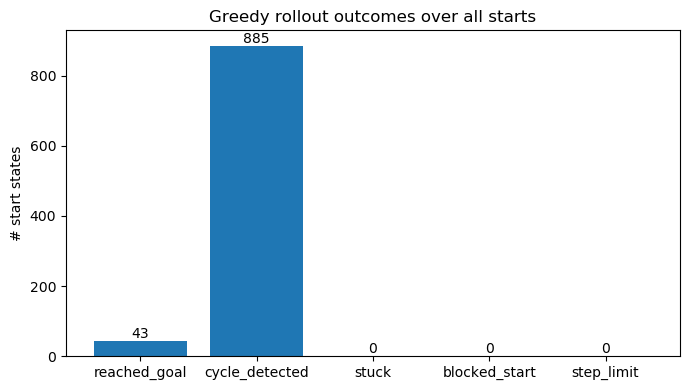

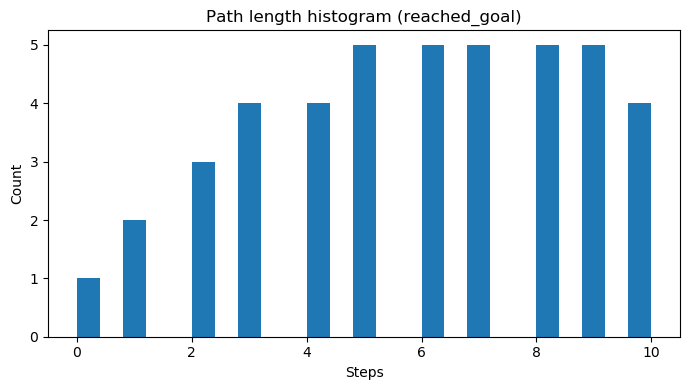

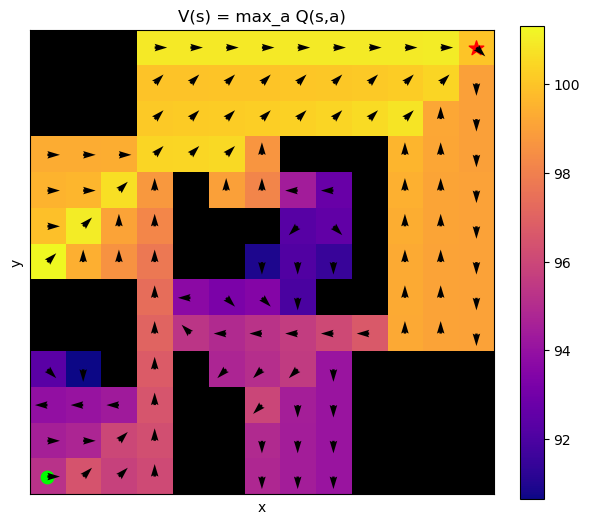

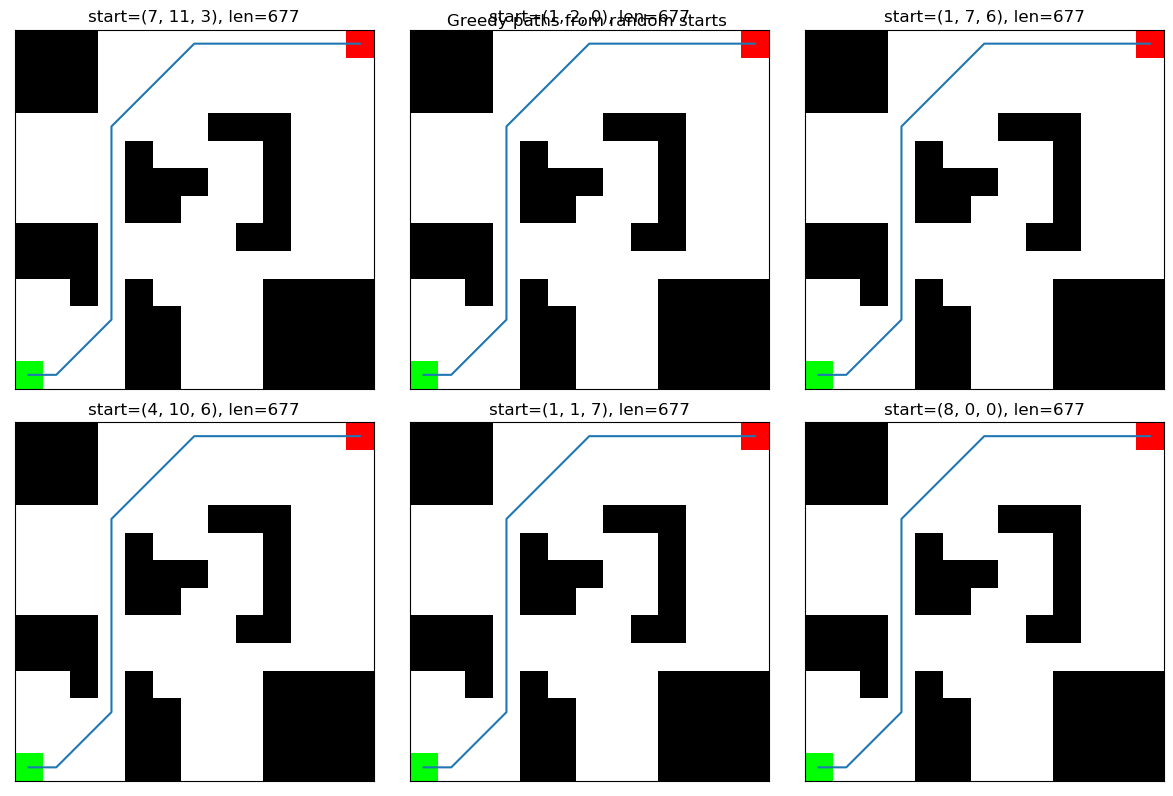

In [3]:
art = load_artifacts("agent.npz")
env2 = rebuild_env_from_artifacts(art)
agent2 = rebuild_agent_from_artifacts(env2, art)

stats = evaluate_all_starts(env2, agent2)
print({k: len(v) for k, v in stats.items()})

plot_success_stats(stats)
plot_path_length_hist(stats, status="reached_goal", bins=25)
plot_value_and_policy(env2, agent2)
sample_and_plot_paths(env2, agent2, n=6)

In [ ]:
# 1) Load & rebuild
art   = load_artifacts("agent.npz")
env   = rebuild_env_from_artifacts(art)
agent = rebuild_agent_from_artifacts(env, art)

# 2) Plot (drop-in function)
def plot_policy_per_angle(env, agent, every=1, head_scale=0.35, act_scale=0.35, save_path=None):
    import matplotlib.pyplot as plt, math, numpy as np
    H, W, K = env.height, env.width, env.num_angles
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True); axes = axes.ravel()

    bg = np.ones((H, W, 3)); bg[env.grid == 1] = (0, 0, 0)
    for k in range(K):
        ax = axes[k]
        ax.imshow(bg, origin="lower", interpolation="nearest")
        ax.set_xlim([-0.5, W-0.5]); ax.set_ylim([-0.5, H-0.5])
        ax.set_xticks(range(W)); ax.set_yticks(range(H))
        ax.set_title(f"k={k} (θ={env.idx_to_angle(k):.2f} rad)")

        xs_h, ys_h, us_h, vs_h = [], [], [], []
        xs_m, ys_m, us_m, vs_m = [], [], [], []
        rot_x, rot_y, rot_txt = [], [], []

        for r in range(0, H, every):
            for c in range(0, W, every):
                if env.grid[r, c] == 1: 
                    continue
                ang = env.idx_to_angle(k)
                xs_h.append(c); ys_h.append(r)
                us_h.append(math.cos(ang)*head_scale); vs_h.append(math.sin(ang)*head_scale)

                q = agent.Q[r, c, k]
                # tie-break: prefer moves over rotations
                best = np.flatnonzero(q == q.max())
                pref = [0, 1, 2] if env.allow_only_forward else [0, 1, 2, 3]
                a = next((p for p in pref if p in best), int(best[0]))

                dr, dc, _ = env.action(k, a)
                if dr != 0 or dc != 0:
                    xs_m.append(c); ys_m.append(r); us_m.append(dc*act_scale); vs_m.append(dr*act_scale)
                else:
                    # rotation symbol
                    sym = "⟲" if (a == 1 if env.allow_only_forward else a == 2) else "⟳"
                    rot_x.append(c); rot_y.append(r); rot_txt.append(sym)

        if xs_h:
            ax.quiver(xs_h, ys_h, us_h, vs_h, angles='xy', scale_units='xy', scale=1,
                      width=0.010, color='lime', zorder=6)
        if xs_m:
            ax.quiver(xs_m, ys_m, us_m, vs_m, angles='xy', scale_units='xy', scale=1,
                      width=0.010, color='red', zorder=7)
        for x, y, s in zip(rot_x, rot_y, rot_txt):
            ax.text(x, y, s, ha='center', va='center', fontsize=10, color='red', zorder=8)

    for i in range(K, len(axes)): axes[i].axis('off')
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

# 3) Call
plot_policy_per_angle(env, agent, save_path="policy_from_objects.png")


FileNotFoundError: [Errno 2] No such file or directory: 'bundle_min.npz'

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def plot_greedy_from_start(env, agent, start, limit=2000, every=1, arrow_scale=0.35, save_path=None):
    """
    start: (r, c, k) or (r, c, theta_rad)
    """
    # normalize start tuple
    r, c, a = start
    k = int(a) if isinstance(a, (int, np.integer)) else env.angle_to_idx(float(a))

    if not (0 <= r < env.height and 0 <= c < env.width):
        raise ValueError("Start out of bounds.")
    if env.grid[r, c] == 1:
        raise ValueError("Start is on an obstacle.")

    # backup & force greedy
    eps_bak = agent.epsilon
    agent.epsilon = 0.0

    # set start
    if not env.reset_new_position((r, c, k)):
        raise ValueError("Failed to set start (unexpected obstacle).")

    # rollout greedy
    s = env.agent_pos
    path = [s]
    for _ in range(limit):
        if s == env.goal:
            break
        a = agent.choose_action(s)
        s, _, done = env.step(a)
        path.append(s)
        if done:
            break

    # restore
    agent.epsilon = eps_bak

    # ---- plot
    H, W = env.height, env.width
    bg = np.ones((H, W, 3)); bg[env.grid == 1] = (0, 0, 0)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(bg, origin="lower", interpolation="nearest")
    ax.set_xlim([-0.5, W-0.5]); ax.set_ylim([-0.5, H-0.5])
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    ax.set_xlabel("x (cols)"); ax.set_ylabel("y (rows)")
    ax.set_title(f"Greedy path from start {(r,c,k)} (limit={limit})")

    # mark start/goal
    # ax.scatter(env.start[1], env.start[0], marker="o", c="lime", s=120, zorder=5, label="env.start")
    ax.scatter(env.goal[1],  env.goal[0],  marker="*", c="red",  s=150, zorder=5, label="env.goal")

    # draw path cells
    for (pr, pc, _) in path:
        if env.grid[pr, pc] == 0 and (pr, pc) not in ((env.start[0], env.start[1]), (env.goal[0], env.goal[1])):
            ax.add_patch(plt.Rectangle((pc-0.5, pr-0.5), 1, 1, fill=True, alpha=0.3, color=(0.5, 0.5, 1), zorder=3))

    # draw orientation arrows along the path
    xs, ys, us, vs = [], [], [], []
    for (pr, pc, kk) in path[::every]:
        ang = env.idx_to_angle(kk)
        xs.append(pc); ys.append(pr)
        us.append(math.cos(ang) * arrow_scale)
        vs.append(math.sin(ang) * arrow_scale)
    if xs:
        ax.quiver(xs, ys, us, vs, angles='xy', scale_units='xy', scale=1,
                  width=0.012, color='yellow', zorder=6)

    # ax.legend(loc="upper right")
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

    return path  # returns the visited state sequence


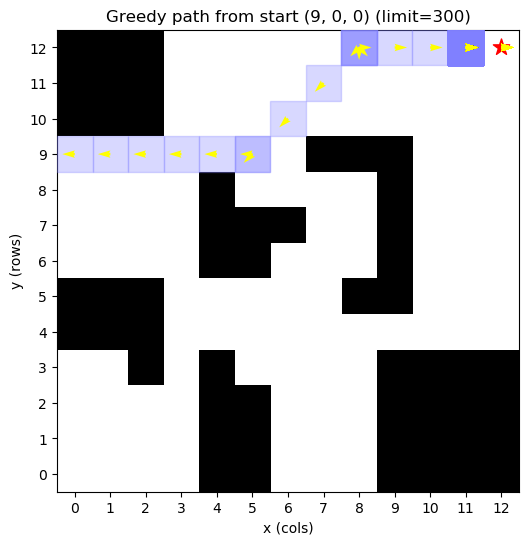

In [ ]:
# Example (after training or after rebuild):
pi = np.pi
start = (9, 0, -pi)  # (y, x, angle_idx) or (y, x, theta_rad)
path = plot_greedy_from_start(env, agent, start=start, limit=300, every=1, save_path="greedy_start_2_1_k0.png")